In [1]:
import os
import joblib
import boto3
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from dotenv import load_dotenv
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

load_dotenv()

# Paths
PROCESSED_DIR = "../data/processed"
MODEL_DIR = "../models"
REPORT_DIR = "../reports/clustering"

os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

# AWS S3
BUCKET = os.getenv("S3_BUCKET_NAME")

s3 = boto3.client(
    "s3",
    aws_access_key_id=os.getenv("AWS_ACCESS_KEY_ID"),
    aws_secret_access_key=os.getenv("AWS_SECRET_ACCESS_KEY"),
    region_name=os.getenv("AWS_REGION")
)

print("Setup complete.")
print("S3 bucket:", BUCKET)

Setup complete.
S3 bucket: aviation-predictive-maintenance-dataset-chamb


In [2]:
def download_if_missing(local_path, s3_key):
    if not os.path.exists(local_path):
        print(f"Downloading {s3_key} from S3...")
        s3.download_file(BUCKET, s3_key, local_path)
        print("Download complete.")
    else:
        print(f"File already exists locally: {local_path}")

train_feat_path = os.path.join(PROCESSED_DIR, "train_features_FD003.parquet")
download_if_missing(train_feat_path, "processed/train_features_FD003.parquet")

File already exists locally: ../data/processed\train_features_FD003.parquet


In [3]:
df = pd.read_parquet(train_feat_path)

print("Dataset shape:", df.shape)
print("Columns:", len(df.columns))
df.head()

Dataset shape: (24720, 75)
Columns: 75


,engine_id,cycle,op_set_1,op_set_2,op_set_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_8_delta_start,sensor_9_delta_start,sensor_11_delta_start,sensor_12_delta_start,sensor_13_delta_start,sensor_14_delta_start,sensor_15_delta_start,sensor_17_delta_start,sensor_20_delta_start,sensor_21_delta_start
0,1,1,-0.0005,0.0004,100.0,518.67,642.36,1583.23,1396.84,14.62,...,0.00,0.00,0.00,0.00,0.00,0.00,0.0000,0,0.00,0.0000
1,1,2,0.0008,-0.0003,100.0,518.67,642.50,1584.69,1396.89,14.62,...,0.04,-0.39,-0.07,0.11,0.02,7.53,0.0157,1,-0.12,0.0954
2,1,3,-0.0014,-0.0002,100.0,518.67,642.18,1582.35,1405.61,14.62,...,0.07,8.06,-0.08,-0.28,-0.01,4.85,-0.0345,0,-0.26,0.0132
3,1,4,-0.0020,0.0001,100.0,518.67,642.92,1585.61,1392.27,14.62,...,0.04,2.40,-0.06,0.18,0.07,1.24,-0.0368,1,-0.15,-0.0586
4,1,5,0.0016,0.0000,100.0,518.67,641.68,1588.63,1397.65,14.62,...,0.08,13.97,-0.15,0.27,0.02,2.48,-0.0377,1,0.03,0.1046


In [4]:
required_cols = ["engine_id", "cycle", "RUL", "label_30"]

missing_required = [col for col in required_cols if col not in df.columns]

if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

print("Required columns are present.")
print("Number of engines:", df["engine_id"].nunique())

Required columns are present.
Number of engines: 100


In [5]:
cluster_features = [c for c in df.columns if c.endswith("_mean_5")]

print("Number of clustering features:", len(cluster_features))
print(cluster_features[:10])

Number of clustering features: 15
['sensor_2_mean_5', 'sensor_3_mean_5', 'sensor_4_mean_5', 'sensor_6_mean_5', 'sensor_7_mean_5', 'sensor_8_mean_5', 'sensor_9_mean_5', 'sensor_11_mean_5', 'sensor_12_mean_5', 'sensor_13_mean_5']


In [6]:
baseline_df = df[df["cycle"] <= 5].copy()

X_clustering = baseline_df.groupby("engine_id")[cluster_features].mean()

print("Engine-level clustering matrix shape:", X_clustering.shape)
X_clustering.head()

Engine-level clustering matrix shape: (100, 15)


,sensor_2_mean_5,sensor_3_mean_5,sensor_4_mean_5,sensor_6_mean_5,sensor_7_mean_5,sensor_8_mean_5,sensor_9_mean_5,sensor_11_mean_5,sensor_12_mean_5,sensor_13_mean_5,sensor_14_mean_5,sensor_15_mean_5,sensor_17_mean_5,sensor_20_mean_5,sensor_21_mean_5
engine_id,,,,,,,,,,,,,,,
1,642.390933,1583.897067,1397.847900,21.610000,554.333333,2387.988033,9064.107433,47.258100,522.321367,2388.020667,8148.223333,8.418405,391.386667,39.026167,23.379164
2,642.137067,1584.093000,1393.947400,21.578433,553.694700,2387.954233,9050.985633,47.110000,521.691700,2387.974267,8135.600233,8.366904,391.433333,38.992733,23.393904
3,642.164033,1585.209400,1397.939000,21.607033,554.555700,2388.005567,9052.264767,47.310633,522.130367,2388.015333,8137.671267,8.392372,391.130000,38.969733,23.418365
4,642.472800,1587.915200,1413.206800,21.610000,553.231933,2388.099533,9048.537133,47.590633,521.304267,2388.109833,8127.975733,8.451140,393.100000,38.748933,23.307480
5,642.931700,1590.573933,1405.532633,21.610000,553.971133,2388.067400,9048.302833,47.448233,521.531267,2388.115800,8129.983967,8.431147,391.910000,38.861400,23.319982


### Clustering design choice

Clustering is performed using the first five operational cycles of each engine.  
This is intended to capture **early-life engine behavior** and segment engines into baseline health groups for proactive maintenance planning.

This supports the project objective of **early prediction** rather than clustering based on the full degradation trajectory.

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clustering)

print("Scaled feature matrix shape:", X_scaled.shape)

Scaled feature matrix shape: (100, 15)


In [8]:
k_values = range(2, 8)
inertias = []
silhouette_scores = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

results_df = pd.DataFrame({
    "k": list(k_values),
    "inertia": inertias,
    "silhouette_score": silhouette_scores
})

results_df

,k,inertia,silhouette_score
0,2,1025.672388,0.299629
1,3,617.638839,0.364614
2,4,508.361201,0.318682
3,5,417.172800,0.318193
4,6,364.957368,0.274323
5,7,333.252370,0.253238


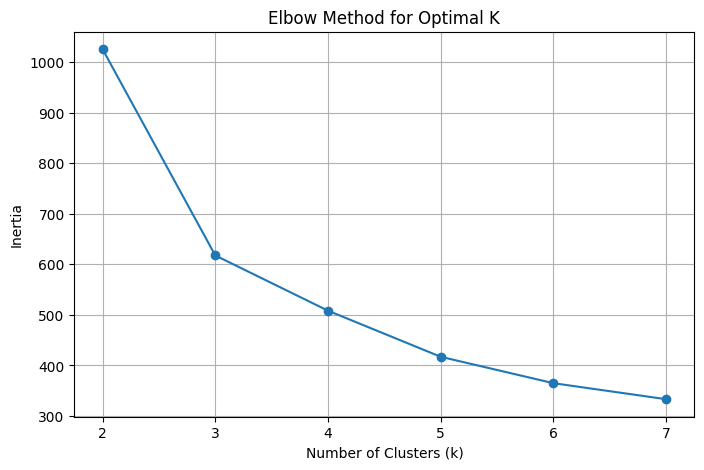

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(results_df["k"], results_df["inertia"], marker="o")
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

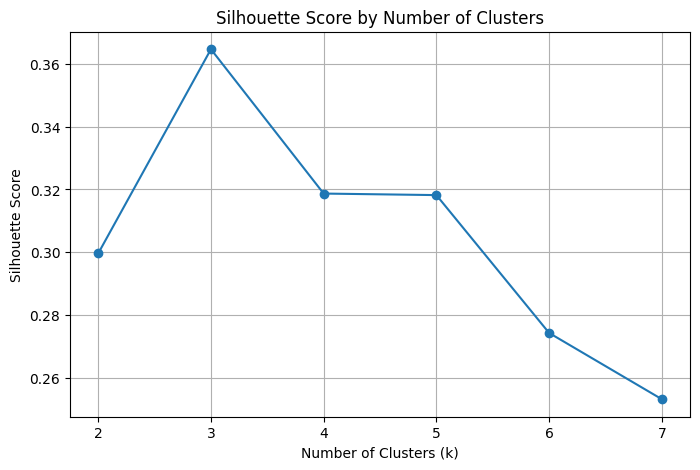

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(results_df["k"], results_df["silhouette_score"], marker="o")
plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

In [11]:
OPTIMAL_K = 3
print(f"Selected K = {OPTIMAL_K}")

Selected K = 3


In [12]:
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

X_clustering = X_clustering.copy()
X_clustering["cluster_label"] = cluster_labels

print("Cluster counts:")
print(X_clustering["cluster_label"].value_counts().sort_index())

Cluster counts:
cluster_label
0    54
1    30
2    16
Name: count, dtype: int64


In [13]:
scaler_path = os.path.join(MODEL_DIR, "kmeans_scaler_FD003.pkl")
kmeans_path = os.path.join(MODEL_DIR, "kmeans_model_FD003.pkl")

joblib.dump(scaler, scaler_path)
joblib.dump(kmeans, kmeans_path)

print("Saved scaler to:", scaler_path)
print("Saved KMeans model to:", kmeans_path)

Saved scaler to: ../models\kmeans_scaler_FD003.pkl
Saved KMeans model to: ../models\kmeans_model_FD003.pkl


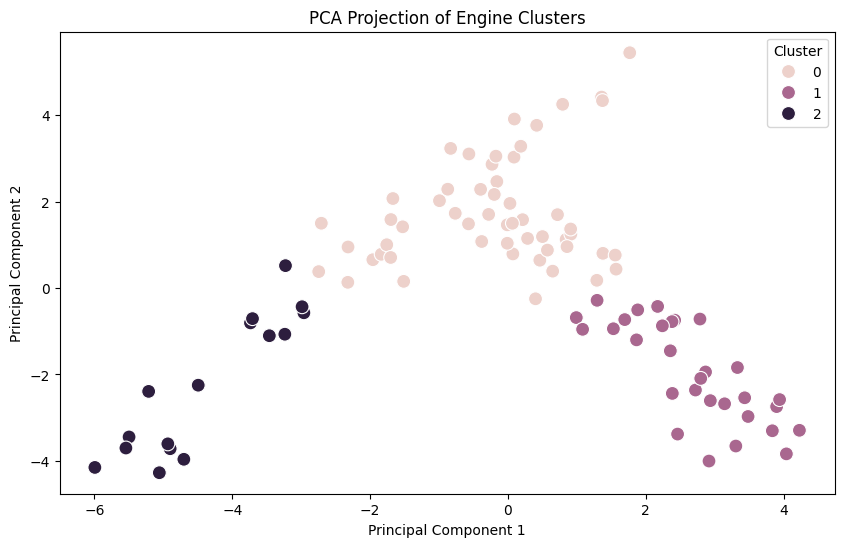

In [14]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"], index=X_clustering.index)
pca_df["cluster_label"] = X_clustering["cluster_label"].values

plt.figure(figsize=(10, 6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="cluster_label", s=100)
plt.title("PCA Projection of Engine Clusters")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()

In [15]:
cluster_profiles = pd.DataFrame(
    scaler.transform(
        X_clustering.drop(columns="cluster_label")
    ),
    columns=X_clustering.drop(columns="cluster_label").columns,
    index=X_clustering.index
)

cluster_profiles["cluster_label"] = X_clustering["cluster_label"]

cluster_profiles = cluster_profiles.groupby("cluster_label").mean()
cluster_profiles

,sensor_2_mean_5,sensor_3_mean_5,sensor_4_mean_5,sensor_6_mean_5,sensor_7_mean_5,sensor_8_mean_5,sensor_9_mean_5,sensor_11_mean_5,sensor_12_mean_5,sensor_13_mean_5,sensor_14_mean_5,sensor_15_mean_5,sensor_17_mean_5,sensor_20_mean_5,sensor_21_mean_5
cluster_label,,,,,,,,,,,,,,,
0,-0.340008,-0.215879,-0.408382,0.102750,0.594365,0.106585,0.447632,-0.340485,0.599493,0.089876,0.575105,-0.650029,-0.311392,0.638413,0.673105
1,1.112604,1.025258,1.240085,0.724174,-0.243247,0.753633,-0.037690,1.202169,-0.202734,0.760177,-0.316077,1.042951,1.078675,-0.901922,-0.914127
2,-0.938606,-1.193768,-0.946871,-1.704608,-1.549895,-1.772787,-1.440088,-1.104931,-1.643163,-1.728665,-1.348334,0.238315,-0.971566,-0.463541,-0.557743


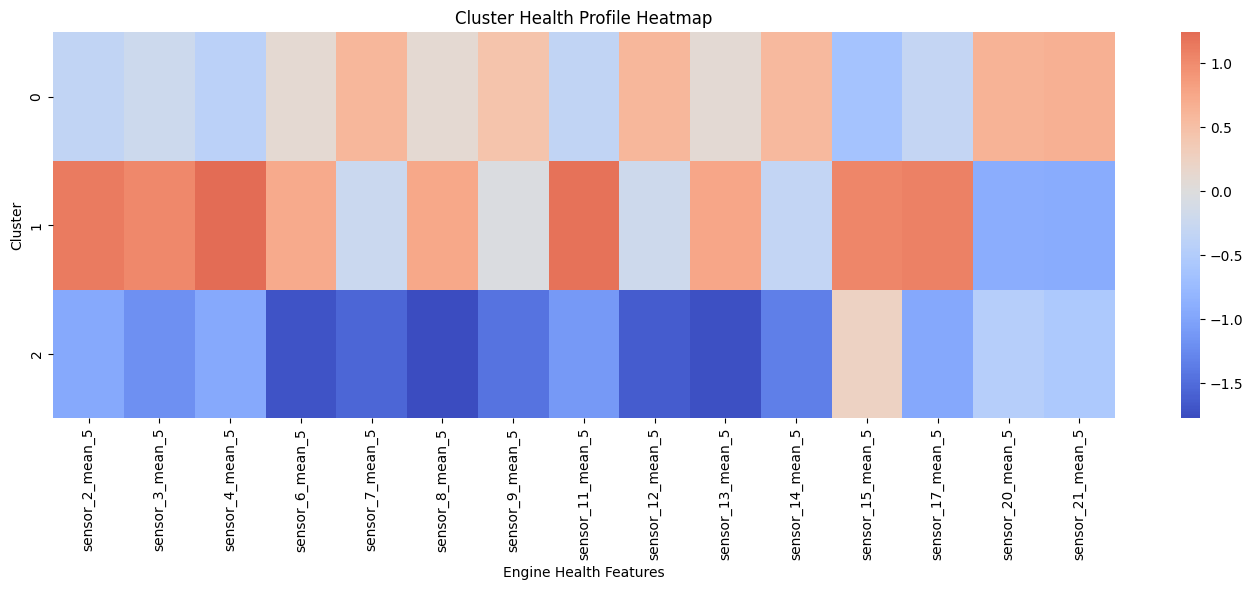

In [16]:
plt.figure(figsize=(14, 6))
sns.heatmap(cluster_profiles, cmap="coolwarm", center=0)
plt.title("Cluster Health Profile Heatmap")
plt.xlabel("Engine Health Features")
plt.ylabel("Cluster")
plt.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, "cluster_health_profiles_FD003.png"), dpi=300)
plt.show()

In [17]:
cluster_mapping = X_clustering[["cluster_label"]].reset_index()

df_clustered = df.merge(cluster_mapping, on="engine_id", how="left")

print("Clustered full dataset shape:", df_clustered.shape)
df_clustered.head()

Clustered full dataset shape: (24720, 76)


,engine_id,cycle,op_set_1,op_set_2,op_set_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_9_delta_start,sensor_11_delta_start,sensor_12_delta_start,sensor_13_delta_start,sensor_14_delta_start,sensor_15_delta_start,sensor_17_delta_start,sensor_20_delta_start,sensor_21_delta_start,cluster_label
0,1,1,-0.0005,0.0004,100.0,518.67,642.36,1583.23,1396.84,14.62,...,0.00,0.00,0.00,0.00,0.00,0.0000,0,0.00,0.0000,0
1,1,2,0.0008,-0.0003,100.0,518.67,642.50,1584.69,1396.89,14.62,...,-0.39,-0.07,0.11,0.02,7.53,0.0157,1,-0.12,0.0954,0
2,1,3,-0.0014,-0.0002,100.0,518.67,642.18,1582.35,1405.61,14.62,...,8.06,-0.08,-0.28,-0.01,4.85,-0.0345,0,-0.26,0.0132,0
3,1,4,-0.0020,0.0001,100.0,518.67,642.92,1585.61,1392.27,14.62,...,2.40,-0.06,0.18,0.07,1.24,-0.0368,1,-0.15,-0.0586,0
4,1,5,0.0016,0.0000,100.0,518.67,641.68,1588.63,1397.65,14.62,...,13.97,-0.15,0.27,0.02,2.48,-0.0377,1,0.03,0.1046,0


In [18]:
missing_cluster_labels = df_clustered["cluster_label"].isnull().sum()
print("Missing cluster labels:", missing_cluster_labels)

if missing_cluster_labels > 0:
    raise ValueError("Some engines did not receive a cluster label.")

Missing cluster labels: 0


In [19]:
cluster_summary = df_clustered.groupby("cluster_label").agg(
    mean_RUL=("RUL", "mean"),
    median_RUL=("RUL", "median"),
    failure_rate_30=("label_30", "mean"),
    engine_count=("engine_id", "nunique")
).sort_values("mean_RUL", ascending=False)

cluster_summary

,mean_RUL,median_RUL,failure_rate_30,engine_count
cluster_label,,,,
2,181.826893,160.0,0.096799,16
0,137.970584,127.0,0.121586,54
1,99.863590,97.0,0.159574,30


In [20]:
ordered_clusters = cluster_summary.index.tolist()

cluster_name_map = {
    ordered_clusters[0]: "Healthy",
    ordered_clusters[1]: "Moderate Degradation",
    ordered_clusters[2]: "High Risk"
}

df_clustered["cluster_name"] = df_clustered["cluster_label"].map(cluster_name_map)
cluster_summary["cluster_name"] = cluster_summary.index.map(cluster_name_map)

cluster_summary

,mean_RUL,median_RUL,failure_rate_30,engine_count,cluster_name
cluster_label,,,,,
2,181.826893,160.0,0.096799,16,Healthy
0,137.970584,127.0,0.121586,54,Moderate Degradation
1,99.863590,97.0,0.159574,30,High Risk


In [21]:
print(df_clustered[["engine_id", "cluster_label", "cluster_name"]].drop_duplicates()["cluster_name"].value_counts())

cluster_name
Moderate Degradation    54
High Risk               30
Healthy                 16
Name: count, dtype: int64


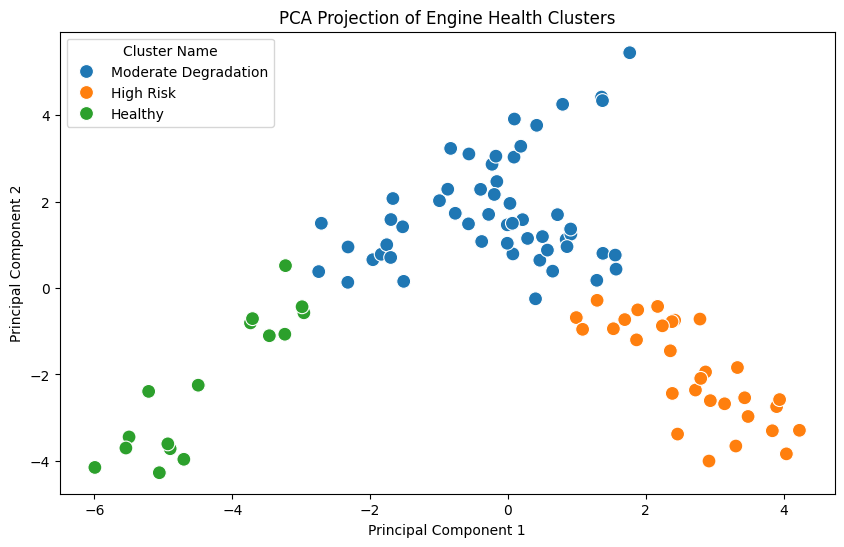

In [22]:
pca_df["cluster_name"] = pca_df["cluster_label"].map(cluster_name_map)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="cluster_name", s=100)
plt.title("PCA Projection of Engine Health Clusters")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster Name")
plt.show()

In [23]:
business_summary = df_clustered.groupby("cluster_name").agg(
    engines=("engine_id", "nunique"),
    avg_RUL=("RUL", "mean"),
    median_RUL=("RUL", "median"),
    failure_rate_30=("label_30", "mean")
).sort_values("avg_RUL", ascending=False)

business_summary

,engines,avg_RUL,median_RUL,failure_rate_30
cluster_name,,,,
Healthy,16,181.826893,160.0,0.096799
Moderate Degradation,54,137.970584,127.0,0.121586
High Risk,30,99.863590,97.0,0.159574


### Cluster interpretation

The clustering analysis segmented engines into three operational health groups:

- **Healthy**: engines with the highest average RUL and lowest short-term failure rate.
- **Moderate Degradation**: engines showing intermediate health characteristics and moderate maintenance attention needs.
- **High Risk**: engines with the lowest average RUL and highest probability of entering the failure window within 30 cycles.

These segments can be used by maintenance planners to prioritize engine inspection and intervention.

In [24]:
clustered_engine_path = os.path.join(PROCESSED_DIR, "engine_clusters_FD003.parquet")
clustered_full_path = os.path.join(PROCESSED_DIR, "train_clustered_FD003.parquet")
cluster_summary_path = os.path.join(PROCESSED_DIR, "cluster_summary_FD003.csv")

X_clustering.reset_index().to_parquet(clustered_engine_path, index=False)
df_clustered.to_parquet(clustered_full_path, index=False)
cluster_summary.to_csv(cluster_summary_path)

print("Saved engine cluster file:", clustered_engine_path)
print("Saved clustered training dataset:", clustered_full_path)
print("Saved cluster summary:", cluster_summary_path)

Saved engine cluster file: ../data/processed\engine_clusters_FD003.parquet
Saved clustered training dataset: ../data/processed\train_clustered_FD003.parquet
Saved cluster summary: ../data/processed\cluster_summary_FD003.csv


In [25]:
s3.upload_file(clustered_engine_path, BUCKET, "processed/engine_clusters_FD003.parquet")
s3.upload_file(clustered_full_path, BUCKET, "processed/train_clustered_FD003.parquet")
s3.upload_file(cluster_summary_path, BUCKET, "processed/cluster_summary_FD003.csv")
s3.upload_file(scaler_path, BUCKET, "models/kmeans_scaler_FD003.pkl")
s3.upload_file(kmeans_path, BUCKET, "models/kmeans_model_FD003.pkl")
s3.upload_file(
    os.path.join(REPORT_DIR, "cluster_health_profiles_FD003.png"),
    BUCKET,
    "reports/cluster_health_profiles_FD003.png"
)

print("Uploaded clustering outputs to S3.")

Uploaded clustering outputs to S3.


In [26]:
final_summary = {
    "input_dataset_rows": len(df),
    "input_dataset_columns": len(df.columns),
    "number_of_engines": df["engine_id"].nunique(),
    "number_of_cluster_features": len(cluster_features),
    "optimal_k": OPTIMAL_K,
    "cluster_counts": X_clustering["cluster_label"].value_counts().sort_index().to_dict(),
    "saved_local_files": [
        clustered_engine_path,
        clustered_full_path,
        cluster_summary_path,
        scaler_path,
        kmeans_path
    ],
    "uploaded_s3_prefixes": [
        "processed/engine_clusters_FD003.parquet",
        "processed/train_clustered_FD003.parquet",
        "processed/cluster_summary_FD003.csv",
        "models/kmeans_scaler_FD003.pkl",
        "models/kmeans_model_FD003.pkl",
        "reports/cluster_health_profiles_FD003.png"
    ]
}

final_summary

{'input_dataset_rows': 24720,
 'input_dataset_columns': 75,
 'number_of_engines': 100,
 'number_of_cluster_features': 15,
 'optimal_k': 3,
 'cluster_counts': {0: 54, 1: 30, 2: 16},
 'saved_local_files': ['../data/processed\\engine_clusters_FD003.parquet',
  '../data/processed\\train_clustered_FD003.parquet',
  '../data/processed\\cluster_summary_FD003.csv',
  '../models\\kmeans_scaler_FD003.pkl',
  '../models\\kmeans_model_FD003.pkl'],
 'uploaded_s3_prefixes': ['processed/engine_clusters_FD003.parquet',
  'processed/train_clustered_FD003.parquet',
  'processed/cluster_summary_FD003.csv',
  'models/kmeans_scaler_FD003.pkl',
  'models/kmeans_model_FD003.pkl',
  'reports/cluster_health_profiles_FD003.png']}